# Graph-DTW on real data (OSM <-> Sweden NVDB, Sundbyberg)

Route-based matching on the real pilot data:
- **A** = OSM `driving_edges` (`edge_id`), **B** = Sweden NVDB `vehicle_edges_directed` (`directed_id`), CRS **EPSG:3006**.

Steps: load -> candidates -> validate B geometry -> `match_routes` (graph-DTW) -> sample & visualize
individual A-edges (whole subgraph, edge a, every projection-based point match).


In [1]:
import sys, os, time
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.wkt import loads as load_wkt

sys.path.append(os.path.abspath(".."))
from network_matching import DuckDBMapMatcher, validate_b_geometry, match_edge_to_bgraph, setup_logging

logger, logfile = setup_logging(console=False)   # writes logs/network_matching_*.log
print("logging to", logfile)


logging to logs/network_matching_20260601_140851.log


## 1. Load real data + generate candidates

In [2]:
m = DuckDBMapMatcher()
m.conn.execute("""CREATE OR REPLACE TABLE driving_edges AS
    SELECT edge_id::BIGINT AS edge_id, ST_GeomFromText(geometry) AS geometry
    FROM '../data/osm_edges.csv';""")
m.conn.execute("""CREATE OR REPLACE TABLE vehicle_edges_directed AS
    SELECT directed_id::BIGINT AS directed_id, ST_GeomFromText(geometry) AS geometry
    FROM '../data/sweden_edges.csv';""")
m.configure_sources(source_a='driving_edges', id_col_a='edge_id', geom_col_a='geometry',
                    source_b='vehicle_edges_directed', id_col_b='directed_id', geom_col_b='geometry',
                    utm_srid=3006)
m.set_parameters(max_distance=30.0)

cand = m.generate_candidate_pairs()
print(f"{len(cand)} candidate pairs over {cand['id_a'].nunique()} A-edges")


25429 candidate pairs over 3408 A-edges


## 2. Validate B geometry (choose snap tolerance)

Sweden's connected edges share endpoints exactly (gap 0), so a small `snap_tolerance_m` (0.5 m) is safe.

In [3]:
bset = {}
for r in cand.itertuples(index=False):
    if r.id_b not in bset:
        g = load_wkt(r.wkt_b)
        if g.geom_type == 'LineString':
            bset[r.id_b] = g
_ = validate_b_geometry(list(bset.items()))


   B-NETWORK GEOMETRY VALIDATION (graph-DTW pre-flight)
edges                 : 2507
endpoints              : 5014
exact-shared endpoints : 5002  (gap == 0)
nearest-other-endpoint gap percentiles (m): {'p50': 21.673239066527383, 'p75': 28.29616248538963, 'p90': 46.5969352474087, 'p95': 51.82315785992066}
endpoints with a near (but unequal) neighbour within tolerance:
   <=  0.05 m : 0
   <=   0.1 m : 0
   <=  0.25 m : 0
   <=   0.5 m : 0
   <=   1.0 m : 0
   <=   2.0 m : 0
degenerate edges       : 0
--------------------------------------------------------
Tip: pick snap_tolerance_m above typical connected-endpoint gaps but well below road spacing.


## 3. Run graph-DTW `match_routes` over all A-edges (parallel)

In [4]:
t = time.time()
routes_long, routes_summary = m.compute_graph_dtw_routes(cand, snap_tolerance_m=0.5, step_meters=5.0, n_jobs=-1)
print(f"done in {time.time()-t:.1f}s")

matched = routes_summary[routes_summary.match_type != 'NO_MATCH']
print(f"matched A-edges : {len(matched)}")
print(f"  1:1            : {(matched.match_type=='1:1').sum()}")
print(f"  multi-edge route: {(matched.match_type=='1:N_ROUTE').sum()}")
print(f"NO_MATCH        : {(routes_summary.match_type=='NO_MATCH').sum()}")
print(f"median drift    : {matched.dtw_distance.median():.2f} m   mean n_edges: {matched.n_edges.mean():.2f}")
display(matched.sort_values('n_edges', ascending=False)
        [['source_id','n_edges','dtw_distance','matched_len','match_type']].head(8))


done in 9.9s
matched A-edges : 3383
  1:1            : 1818
  multi-edge route: 1565
NO_MATCH        : 565
median drift    : 2.45 m   mean n_edges: 1.70


,source_id,n_edges,dtw_distance,matched_len,match_type
1860,2137,6,3.663981,499.194565,1:N_ROUTE
1474,1702,6,1.028650,260.907517,1:N_ROUTE
816,930,6,17.343603,240.692380,1:N_ROUTE
1095,1256,6,2.727412,298.469968,1:N_ROUTE
1437,1665,6,2.453249,215.415349,1:N_ROUTE
1951,2251,5,1.270432,99.507963,1:N_ROUTE
3040,3556,5,1.134917,260.122963,1:N_ROUTE
779,888,5,7.474139,150.943689,1:N_ROUTE


## 4. Visualization helper

For one A-edge: pull its candidate B-subgraph (UTM) from `cand`, run graph-DTW, and plot the whole
subgraph, edge a, and every point match. Coordinates are recentered to local meters for readability.

- B-edges: green = in route, gray = unused. Vertices: hollow = B node, small gray = projection,
  purple ring = junction. Match links: crimson `o` = matched to a node, orange `x` = to a projection.


In [5]:
def subgraph_for(cand, id_a):
    grp = cand[cand.id_a == id_a]
    coords_a = list(load_wkt(grp.wkt_a.iloc[0]).coords)
    b_edges = []
    for r in grp.itertuples(index=False):
        g = load_wkt(r.wkt_b)
        if g.geom_type == 'LineString':
            b_edges.append((r.id_b, g))
    return coords_a, b_edges

def plot_real(id_a, cand, snap_tolerance_m=0.5, step_meters=5.0):
    coords_a, b_edges = subgraph_for(cand, id_a)
    res = match_edge_to_bgraph(coords_a, b_edges, snap_tolerance_m=snap_tolerance_m, step_meters=step_meters)
    gb = res["graph"]; m = res["metrics"]
    route_ids = [e for (e, _d, _s) in res["route"]]

    # recenter to local meters
    allx = [p[0] for p in coords_a] + list(gb.vx)
    ally = [p[1] for p in coords_a] + list(gb.vy)
    ox, oy = min(allx), min(ally)
    rc = lambda x, y: (x - ox, y - oy)

    fig, ax = plt.subplots(figsize=(12, 7))
    for eid, geom in b_edges:
        xs, ys = geom.xy
        inr = eid in route_ids
        ax.plot([x - ox for x in xs], [y - oy for y in ys],
                color=("seagreen" if inr else "silver"), lw=(4 if inr else 1.5),
                alpha=(0.9 if inr else 0.6), zorder=2)

    vx = gb.vx - ox; vy = gb.vy - oy; isn = gb.is_node
    ax.scatter(vx[isn], vy[isn], s=40, facecolors="white", edgecolors="dimgray", linewidths=1.1,
               zorder=3, label="B node")
    ax.scatter(vx[~isn], vy[~isn], s=12, c="lightgray", zorder=3, label="B projection point")
    vedges = defaultdict(set)
    for v in range(gb.n_vertices):
        for (w, e, _d) in gb.succ_arcs[v]:
            vedges[v].add(e); vedges[w].add(e)
    jun = [v for v, es in vedges.items() if len(es) > 1]
    if jun:
        ax.scatter(vx[jun], vy[jun], s=120, facecolors="none", edgecolors="purple",
                   linewidths=1.6, zorder=4, label="junction")

    xa = [p[0] - ox for p in coords_a]; ya = [p[1] - oy for p in coords_a]
    ax.plot(xa, ya, color="royalblue", lw=2.5, zorder=5, label="A-edge (OSM)")

    pp = pj = False
    for (pa, pb), isnode in zip(res["warping_path"], m["warp_is_node"]):
        pax, pay = rc(*pa); pbx, pby = rc(*pb)
        col = "crimson" if isnode else "darkorange"
        ax.plot([pax, pbx], [pay, pby], color=col, lw=0.8, alpha=0.85, zorder=4)
        ax.scatter([pax], [pay], s=9, c="royalblue", zorder=6)
        lbl = None
        if isnode and not pp: lbl = "match -> B node"; pp = True
        elif (not isnode) and not pj: lbl = "match -> B projection"; pj = True
        ax.scatter([pbx], [pby], s=30, marker=("o" if isnode else "x"), c=col, zorder=6, label=lbl)

    ax.set_title(f"OSM edge {id_a}  ->  route {[e for e,_,_ in res['route']]}\n"
                 f"avg drift={res['avg_distance']:.2f} m   n_edges={m['n_edges']}   "
                 f"matched_len={m['matched_len']:.1f} m")
    ax.legend(loc="best", fontsize=8); ax.set_aspect("equal", "box"); ax.grid(alpha=0.3)
    ax.set_xlabel("x (m, local)"); ax.set_ylabel("y (m, local)")
    plt.tight_layout(); plt.show()
    return res


## 5. Sample multi-edge routes (segmentation-split stitching)

A-edges whose OSM segment spans several NVDB segments -- graph-DTW stitches them into one route.

sampling multi-edge OSM edges: [1671, 1670, 2560]


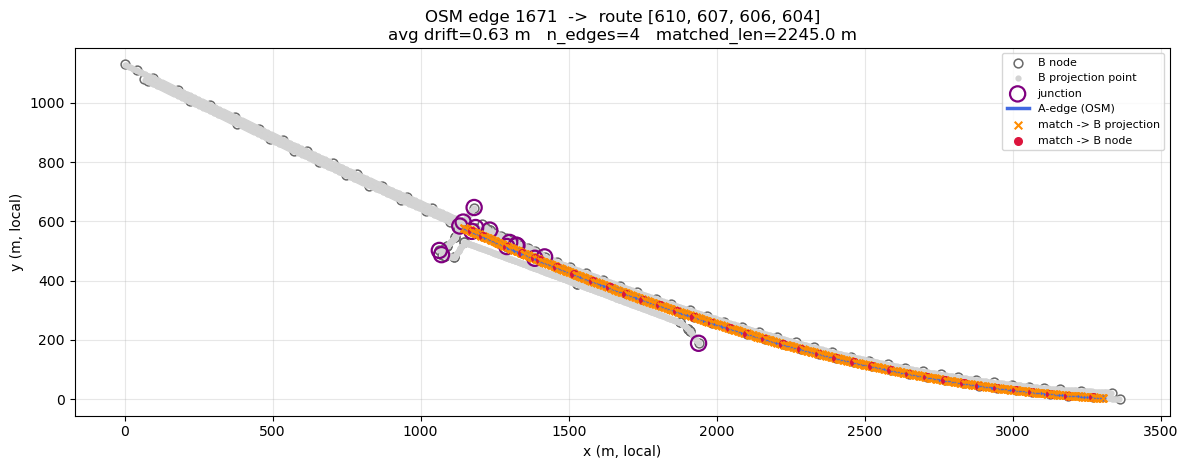

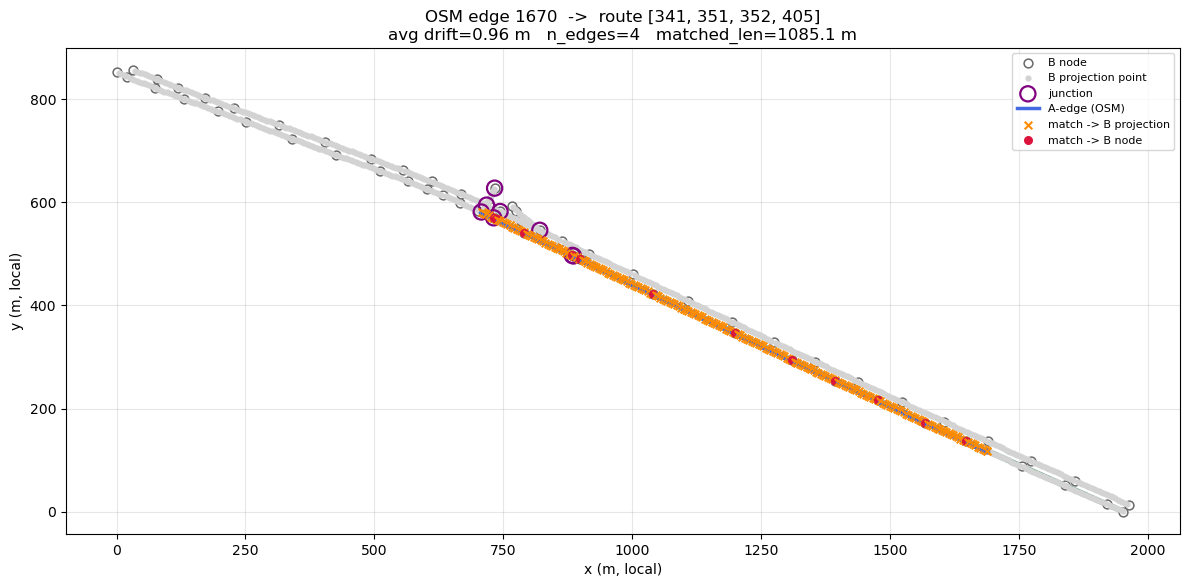

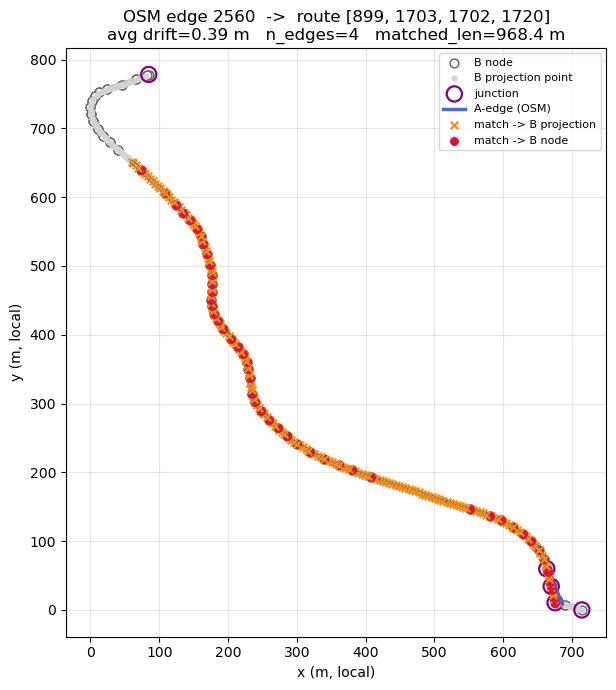

In [6]:
multi = matched[matched.n_edges >= 3].sort_values('matched_len', ascending=False)
sample_ids = multi.source_id.head(3).tolist()
print("sampling multi-edge OSM edges:", sample_ids)
for sid in sample_ids:
    plot_real(sid, cand)


## 6. Sample clean 1:1 and a higher-drift case

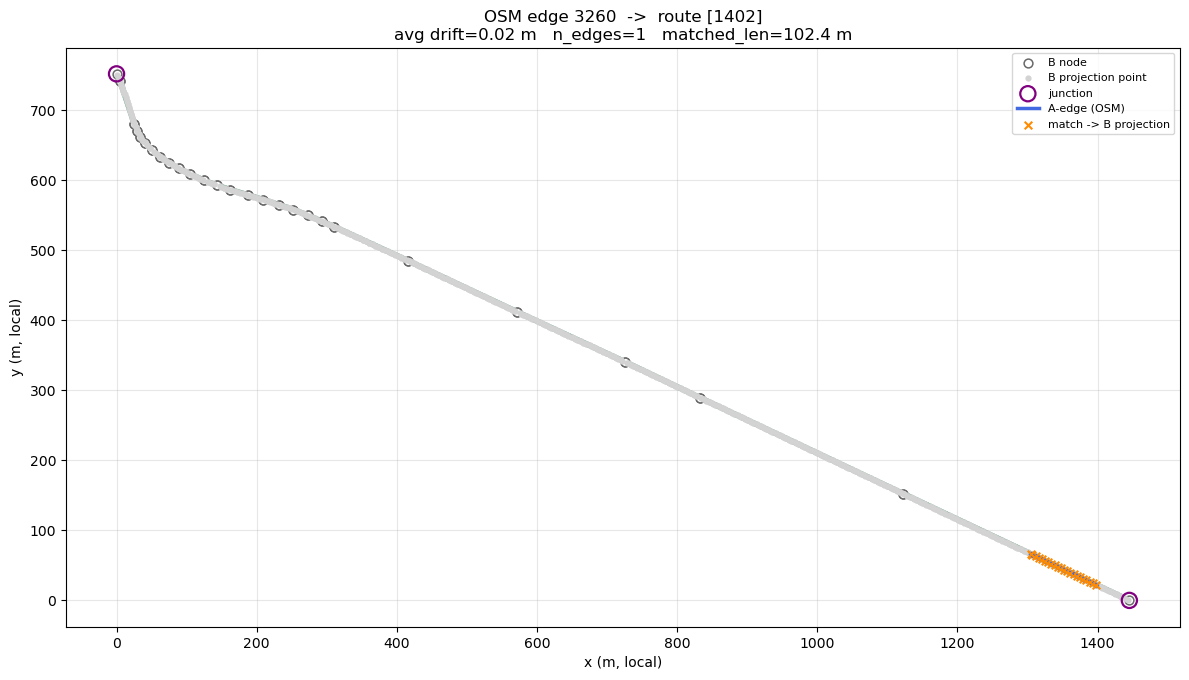

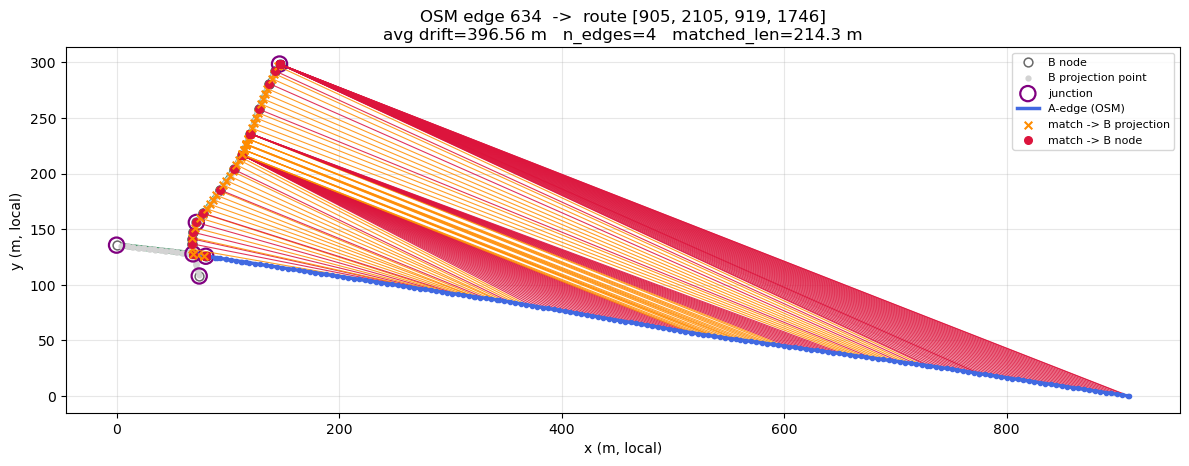

In [7]:
one = matched[(matched.match_type=='1:1') & (matched.matched_len>40)].sort_values('dtw_distance')
if len(one):
    plot_real(one.source_id.iloc[0], cand)            # clean 1:1
high = matched.sort_values('dtw_distance', ascending=False)
if len(high):
    plot_real(high.source_id.iloc[0], cand)           # largest-drift matched edge
